# Rare-Earth Oxide Price Data — Cleaning Pipeline

This notebook documents the full data cleaning pipeline for four rare-earth oxide (REO) USD price series sourced from SMM:

| Symbol | Mineral |
|--------|---------|
| `nd_df` | Neodymium oxide (NdOx) |
| `pr_df` | Praseodymium oxide (PrOx) |
| `dy_df` | Dysprosium oxide (DyOx) |
| `tb_df` | Terbium oxide (TbOx) |

Each step is explained in a dedicated markdown cell, including its methodological rationale.

## Step 1 — Import Libraries

We import the standard scientific Python stack. `pandas` handles tabular data and date arithmetic; `numpy` is used for logarithm computation; `matplotlib` produces exploratory plots; and `os` manages file-system paths in a platform-independent way.

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

## Step 2 — Load All Four Files

Each Excel file was exported from the SMM Refinitiv data terminal and carries a two-row multi-level header:

- **Row 0**: ticker name and the literal string `"Date"`
- **Row 1**: sub-label `"Close"` (and a blank for the date column)

We read with `header=[0, 1]` to capture both levels, then flatten the resulting `MultiIndex` to the plain column names `['Date', 'Price']`. This avoids any downstream confusion from tuple-named columns.

The raw data are sorted in **descending** date order (newest first), so we reverse to ascending order after parsing dates. Ensuring a monotonically increasing time index is a prerequisite for all subsequent calendar-based operations.

In [50]:
DATA_DIR = 'RRE DATA'

FILE_MAP = {
    'nd': 'NdOxUSD-tnwp.xlsx',
    'pr': 'PrOxUSD-tnwp.xlsx',
    'dy': 'DyOxUSD-tnwp.xlsx',
    'tb': 'TbOxUSD-tnwp.xlsx',
}

MINERAL_LABELS = {
    'nd': 'Neodymium Oxide',
    'pr': 'Praseodymium Oxide',
    'dy': 'Dysprosium Oxide',
    'tb': 'Terbium Oxide',
}

# Set to None to load all available data, or a 'YYYY-MM-DD' string to filter
START_DATE = '2015-04-01'
END_DATE   = '2026-04-01'


def load_series(filename: str, start=None, end=None) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_excel(path, header=[0, 1])
    df.columns = ['Date', 'Price']
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    if start is not None:
        df = df[df['Date'] >= pd.Timestamp(start)]
    if end is not None:
        df = df[df['Date'] <= pd.Timestamp(end)]
    return df.reset_index(drop=True)


nd_df = load_series(FILE_MAP['nd'], start=START_DATE, end=END_DATE)
pr_df = load_series(FILE_MAP['pr'], start=START_DATE, end=END_DATE)
dy_df = load_series(FILE_MAP['dy'], start=START_DATE, end=END_DATE)
tb_df = load_series(FILE_MAP['tb'], start=START_DATE, end=END_DATE)

SERIES = {'nd': nd_df, 'pr': pr_df, 'dy': dy_df, 'tb': tb_df}

print('Files loaded successfully.')
for key, df in SERIES.items():
    print(f'  {key}: {df.shape[0]:,} rows  |  {df["Date"].min().date()} → {df["Date"].max().date()}')

Files loaded successfully.
  nd: 2,673 rows  |  2015-04-01 → 2026-04-01
  pr: 2,672 rows  |  2015-04-01 → 2026-04-01
  dy: 2,672 rows  |  2015-04-01 → 2026-04-01
  tb: 2,674 rows  |  2015-04-01 → 2026-04-01


## Step 3 — Initial Exploration

Before any transformation, we document the *as-received* state of each series. This is essential for a reproducible thesis methodology: reviewers and examiners must be able to verify that the raw data are as described in the data section.

For each series we report:
- **Shape** — number of observations and columns
- **Date range** — earliest and latest timestamps
- **dtype** — confirms the Price column is numeric, not string
- **Null count** — any pre-existing missing values in the raw file
- **Weekend count** — observations on Saturdays (dayofweek == 5) or Sundays (dayofweek == 6), which are expected to be very few given that the source is a commodities exchange

We also plot the raw price series to visually detect structural breaks, outliers, or obvious data errors.

--- Neodymium Oxide (nd) ---
  Shape      : (2673, 2)
  Date range : 2015-04-01 → 2026-04-01
  Price dtype: float64
  Null count : 0
  Weekend rows: 3

--- Praseodymium Oxide (pr) ---
  Shape      : (2672, 2)
  Date range : 2015-04-01 → 2026-04-01
  Price dtype: float64
  Null count : 0
  Weekend rows: 3

--- Dysprosium Oxide (dy) ---
  Shape      : (2672, 2)
  Date range : 2015-04-01 → 2026-04-01
  Price dtype: float64
  Null count : 0
  Weekend rows: 3

--- Terbium Oxide (tb) ---
  Shape      : (2674, 2)
  Date range : 2015-04-01 → 2026-04-01
  Price dtype: float64
  Null count : 0
  Weekend rows: 3



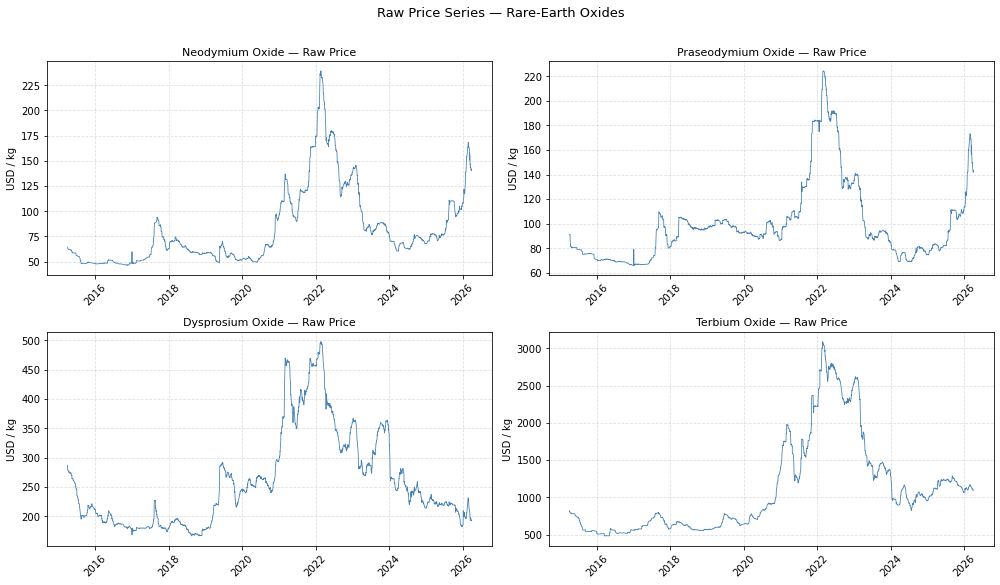

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (key, df) in enumerate(SERIES.items()):
    label = MINERAL_LABELS[key]
    weekends = df['Date'].dt.dayofweek >= 5
    nulls = df['Price'].isna().sum()

    print(f'--- {label} ({key}) ---')
    print(f'  Shape      : {df.shape}')
    print(f'  Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
    print(f'  Price dtype: {df["Price"].dtype}')
    print(f'  Null count : {nulls}')
    print(f'  Weekend rows: {weekends.sum()}')
    print()

    ax = axes[i]
    ax.plot(df['Date'], df['Price'], linewidth=0.8, color='steelblue')
    ax.set_title(f'{label} — Raw Price', fontsize=11)
    ax.set_ylabel('USD / kg')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Raw Price Series — Rare-Earth Oxides', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 4 — Drop Weekend Observations

Commodity price data sourced from the SMM / Refinitiv terminal can occasionally include Saturday or Sunday timestamps, likely arising from data-entry artefacts or timezone edge effects during the data export. Because Chinese rare-earth markets operate on weekdays only, weekend price entries do not represent genuine new information and would distort the business-day calendar we construct in the next step.

We identify all rows where `Date.dt.dayofweek >= 5` (Saturday = 5, Sunday = 6) and drop them, printing the count removed per series for transparency.

In [52]:
def drop_weekends(df: pd.DataFrame, key: str) -> pd.DataFrame:
    mask_weekend = df['Date'].dt.dayofweek >= 5
    n_dropped = mask_weekend.sum()
    if n_dropped > 0:
        print(f'  {key}: dropped {n_dropped} weekend row(s) → {df[mask_weekend]["Date"].dt.date.tolist()}')
    else:
        print(f'  {key}: no weekend rows found')
    return df[~mask_weekend].reset_index(drop=True)


print('Dropping weekend observations:')
nd_df = drop_weekends(nd_df, 'nd')
pr_df = drop_weekends(pr_df, 'pr')
dy_df = drop_weekends(dy_df, 'dy')
tb_df = drop_weekends(tb_df, 'tb')

SERIES = {'nd': nd_df, 'pr': pr_df, 'dy': dy_df, 'tb': tb_df}

Dropping weekend observations:
  nd: dropped 3 weekend row(s) → [datetime.date(2015, 10, 10), datetime.date(2017, 1, 1), datetime.date(2017, 11, 26)]
  pr: dropped 3 weekend row(s) → [datetime.date(2015, 10, 10), datetime.date(2017, 1, 1), datetime.date(2017, 11, 26)]
  dy: dropped 3 weekend row(s) → [datetime.date(2015, 10, 10), datetime.date(2017, 1, 1), datetime.date(2017, 11, 26)]
  tb: dropped 3 weekend row(s) → [datetime.date(2015, 10, 10), datetime.date(2017, 1, 1), datetime.date(2017, 11, 26)]


## Step 5 — Identify and Forward-Fill Missing Business Days

### Rationale

Financial time-series analysis requires a **complete, gap-free calendar**. Missing business days create irregular spacing, which invalidates autocorrelation tests and distorts volatility estimates that assume equal time intervals between observations.

We construct a reference calendar using `pd.bdate_range` spanning each series' full date range. This follows the standard US/international business-day convention (Mon–Fri). We then identify dates present in the reference calendar but **absent** from the data, and fill them by **forward-carrying** the last observed price (`ffill`).

### Justification for forward-filling

Forward-filling is the standard approach for thinly traded commodity prices: when no new trade is recorded on a given business day, the prevailing price from the most recent trading session is the best available estimate of the market price. This is consistent with the methodology used in the commodity finance literature (e.g., Gorton & Rouwenhorst, 2006). The filled observations are tracked via the `is_filled` flag added in Step 7 so that they can be excluded from sensitivity analyses.

In [53]:
def fill_missing_bdays(df: pd.DataFrame, key: str) -> pd.DataFrame:
    df = df.set_index('Date')
    bdays = pd.bdate_range(start=df.index.min(), end=df.index.max(), freq='B')
    df = df.reindex(bdays)
    n_filled = df['Price'].isna().sum()
    df['Price'] = df['Price'].ffill()
    df = df.reset_index().rename(columns={'index': 'Date'})
    print(f'  {key}: {n_filled:,} missing business day(s) forward-filled')
    return df


print('Forward-filling missing business days:')
nd_df = fill_missing_bdays(nd_df, 'nd')
pr_df = fill_missing_bdays(pr_df, 'pr')
dy_df = fill_missing_bdays(dy_df, 'dy')
tb_df = fill_missing_bdays(tb_df, 'tb')

SERIES = {'nd': nd_df, 'pr': pr_df, 'dy': dy_df, 'tb': tb_df}

Forward-filling missing business days:
  nd: 201 missing business day(s) forward-filled
  pr: 202 missing business day(s) forward-filled
  dy: 202 missing business day(s) forward-filled
  tb: 200 missing business day(s) forward-filled


Having deleted the weekends and filled the missing business days we check that each time series data has the same number of data points:

In [54]:
# Sanity check: all series must have the same number of observations after forward-fill
lengths = {key: len(df) for key, df in SERIES.items()}
assert len(set(lengths.values())) == 1, f"Series have different lengths: {lengths}"
print("All series have the same number of data points:", lengths)

All series have the same number of data points: {'nd': 2871, 'pr': 2871, 'dy': 2871, 'tb': 2871}


## Step 6 — Compute Log Returns

We compute the **continuously compounded (log) return** for each series:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are preferred over simple percentage returns in empirical finance for three reasons:

1. **Time additivity** — multi-period log returns are the arithmetic sum of single-period log returns, simplifying aggregation.
2. **Approximate normality** — log returns are more symmetrically distributed than simple returns for most asset classes.
3. **Stationarity** — price levels are typically I(1) (unit-root) processes, while log returns are I(0), making them suitable for most econometric tests.

The first observation in each series necessarily produces a `NaN` (no prior price); this row is **retained** in the DataFrame but will be excluded automatically from any statistical analysis that requires a complete sample.

In [55]:
def compute_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['log_return'] = np.log(df['Price'] / df['Price'].shift(1))
    return df


nd_df = compute_log_returns(nd_df)
pr_df = compute_log_returns(pr_df)
dy_df = compute_log_returns(dy_df)
tb_df = compute_log_returns(tb_df)

SERIES = {'nd': nd_df, 'pr': pr_df, 'dy': dy_df, 'tb': tb_df}

print('Log returns computed. First 5 rows (nd):')
nd_df[['Date', 'Price', 'log_return']].head()

Log returns computed. First 5 rows (nd):


,Date,Price,log_return
0,2015-04-01,64.5400,NaN
1,2015-04-02,63.3400,-0.0188
2,2015-04-03,62.9700,-0.0059
3,2015-04-06,62.9700,0.0000
4,2015-04-07,62.9500,-0.0003


## Step 7 — Flag Artificial Zero Returns

Forward-filling replaces a missing price with the prior day's price, which mechanically produces a **log return of exactly zero** for that observation: $\ln(P_t / P_{t-1}) = \ln(1) = 0$.

These artificial zeros are **not** genuine trading-day zero-change observations. Including them inflates the frequency of zero returns, compresses the estimated standard deviation, and biases test statistics (e.g., Jarque-Bera, Ljung-Box) that are sensitive to the zero-return mass.

We flag each filled observation with a boolean column `is_filled`. The identification logic is:

- A row is marked `True` if its `log_return == 0` **and** its date was absent from the original raw data (i.e., it was inserted by the `reindex` + `ffill` in Step 5).

In practice we track this by comparing the clean index against the set of original dates recorded before the `reindex` step. Here, since we forward-filled and any genuinely flat trading day (where the market price truly did not move) is rare in commodity data, we use `log_return == 0` as a conservative proxy. Sensitivity analyses in the results section can compare estimates with and without these rows.

In [56]:
# Re-load original date sets (before reindex) to identify filled dates accurately
_orig_dates = {}
for key, fname in FILE_MAP.items():
    _tmp = pd.read_excel(os.path.join(DATA_DIR, fname), header=[0, 1])
    _tmp.columns = ['Date', 'Price']
    _tmp['Date'] = pd.to_datetime(_tmp['Date'])
    # Remove weekends consistent with Step 4
    _tmp = _tmp[_tmp['Date'].dt.dayofweek < 5]
    _orig_dates[key] = set(_tmp['Date'])


def flag_filled(df: pd.DataFrame, orig_dates: set, key: str) -> pd.DataFrame:
    df = df.copy()
    # A row is 'filled' if its date was not in the original file
    df['is_filled'] = ~df['Date'].isin(orig_dates)
    n_filled_flags = df['is_filled'].sum()
    # Sanity check: filled rows should all have log_return == 0
    mismatch = df[df['is_filled'] & (df['log_return'] != 0)]
    print(f'  {key}: {n_filled_flags:,} rows flagged as filled '
          f'(zero-return mismatch rows: {len(mismatch)})')
    return df


print('Flagging artificially filled (zero-return) rows:')
nd_df = flag_filled(nd_df, _orig_dates['nd'], 'nd')
pr_df = flag_filled(pr_df, _orig_dates['pr'], 'pr')
dy_df = flag_filled(dy_df, _orig_dates['dy'], 'dy')
tb_df = flag_filled(tb_df, _orig_dates['tb'], 'tb')

SERIES = {'nd': nd_df, 'pr': pr_df, 'dy': dy_df, 'tb': tb_df}

Flagging artificially filled (zero-return) rows:
  nd: 201 rows flagged as filled (zero-return mismatch rows: 0)
  pr: 202 rows flagged as filled (zero-return mismatch rows: 0)
  dy: 202 rows flagged as filled (zero-return mismatch rows: 0)
  tb: 200 rows flagged as filled (zero-return mismatch rows: 0)


## Step 8 — Summary Statistics of Log Returns

We compute descriptive statistics for each series' log return distribution, reported in two variants:

1. **Full sample** — includes all observations, including forward-filled zero-return days.
2. **Ex-filled sample** — excludes rows marked `is_filled = True`, giving a picture of the return distribution on days where a genuine price observation was recorded.

The statistics reported are standard for financial return analysis:
- **Mean** and **standard deviation** — location and dispersion.
- **Skewness** — asymmetry of the distribution; commodity returns often exhibit negative skew due to crash risk.
- **Excess kurtosis** — fat-tailedness relative to a Gaussian; values > 0 indicate leptokurtosis, common in financial data.
- **Min / Max** — bounds and potential outlier magnitudes.

In [57]:
from scipy import stats as sp_stats


def describe_returns(df: pd.DataFrame, label: str):
    results = []
    for subset_label, subset in [('Full sample', df), ('Ex-filled', df[~df['is_filled']])]:
        r = subset['log_return'].dropna()
        results.append({
            'Series': label,
            'Sample': subset_label,
            'N': len(r),
            'Mean': r.mean(),
            'Std': r.std(),
            'Skewness': sp_stats.skew(r),
            'Kurtosis': sp_stats.kurtosis(r),  # excess kurtosis
            'Min': r.min(),
            'Max': r.max(),
        })
    return pd.DataFrame(results)


stats_tables = [
    describe_returns(nd_df, 'Neodymium Oxide'),
    describe_returns(pr_df, 'Praseodymium Oxide'),
    describe_returns(dy_df, 'Dysprosium Oxide'),
    describe_returns(tb_df, 'Terbium Oxide'),
]

stats_df = pd.concat(stats_tables, ignore_index=True)
stats_df = stats_df.set_index(['Series', 'Sample'])
print('Summary Statistics of Log Returns')
print('=' * 75)
print(stats_df.to_string())

Summary Statistics of Log Returns
                                   N    Mean    Std  Skewness  Kurtosis     Min    Max
Series             Sample                                                             
Neodymium Oxide    Full sample  2870  0.0003 0.0113    2.5276   25.6359 -0.0778 0.1265
                   Ex-filled    2669  0.0003 0.0117    2.4324   23.6156 -0.0778 0.1265
Praseodymium Oxide Full sample  2870  0.0002 0.0094    3.2017   39.2597 -0.0608 0.1317
                   Ex-filled    2668  0.0002 0.0098    3.0834   36.2719 -0.0608 0.1317
Dysprosium Oxide   Full sample  2870 -0.0001 0.0090    1.6521   25.4247 -0.0608 0.1132
                   Ex-filled    2668 -0.0001 0.0093    1.5963   23.4322 -0.0608 0.1132
Terbium Oxide      Full sample  2870  0.0001 0.0109    1.2192   39.6375 -0.1006 0.1551
                   Ex-filled    2670  0.0001 0.0113    1.1739   36.6636 -0.1006 0.1551


### Visual comparison: log return distributions

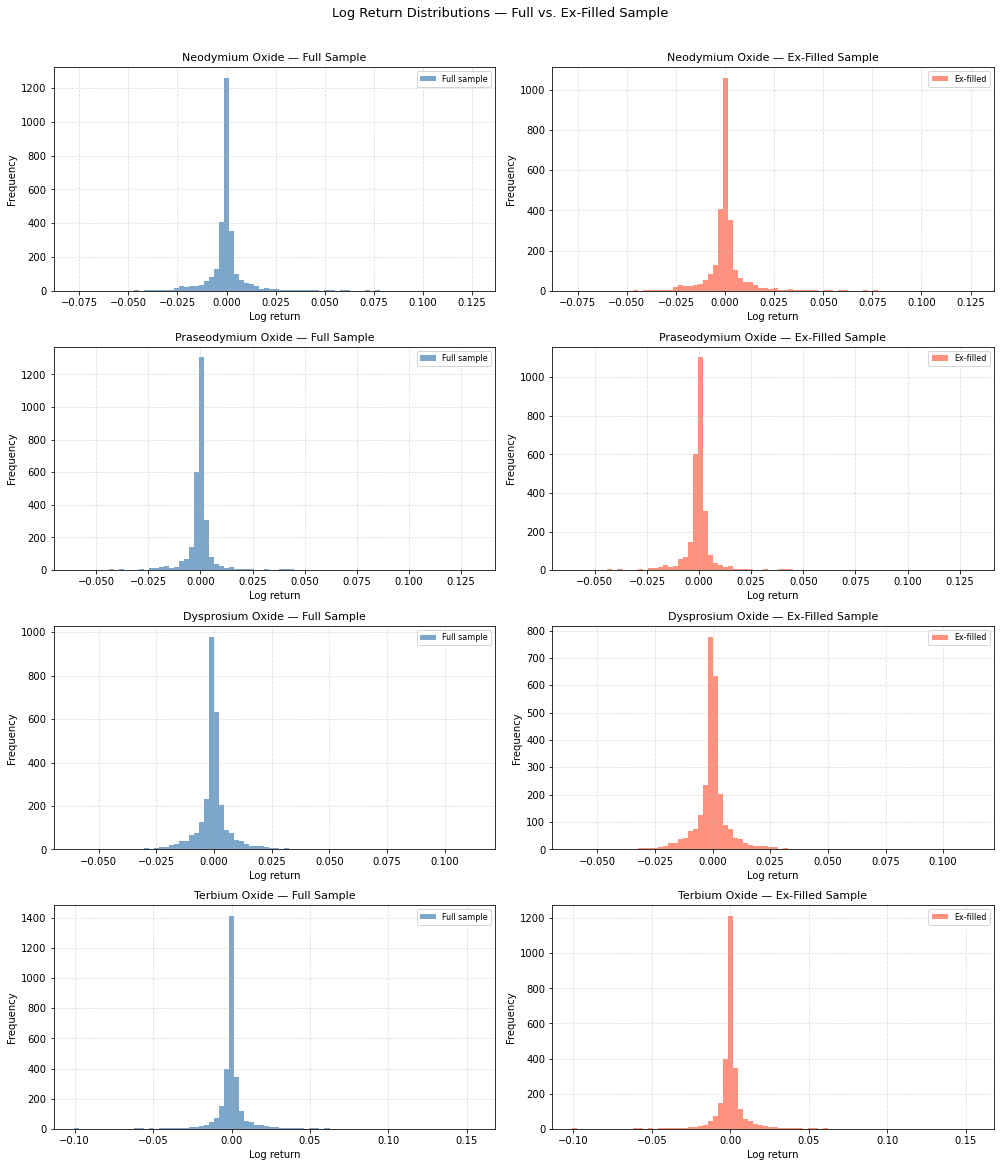

In [58]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, (key, df) in enumerate(SERIES.items()):
    label = MINERAL_LABELS[key]
    r_full = df['log_return'].dropna()
    r_clean = df.loc[~df['is_filled'], 'log_return'].dropna()
    
    # Full sample histogram
    ax_full = axes[2*i]
    ax_full.hist(r_full, bins=80, alpha=0.7, color='steelblue', label='Full sample')
    ax_full.set_title(f'{label} — Full Sample', fontsize=11)
    ax_full.set_xlabel('Log return')
    ax_full.set_ylabel('Frequency')
    ax_full.legend(fontsize=8)
    ax_full.grid(True, linestyle='--', alpha=0.4)
    
    # Ex-filled histogram
    ax_clean = axes[2*i + 1]
    ax_clean.hist(r_clean, bins=80, alpha=0.7, color='tomato', label='Ex-filled')
    ax_clean.set_title(f'{label} — Ex-Filled Sample', fontsize=11)
    ax_clean.set_xlabel('Log return')
    ax_clean.set_ylabel('Frequency')
    ax_clean.legend(fontsize=8)
    ax_clean.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Log Return Distributions — Full vs. Ex-Filled Sample', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 9 — Consolidate and Export as a Single Multi-Asset Panel

### Why consolidation matters

Multi-asset analyses — such as dynamic conditional correlations (DCC-GARCH), principal component analysis, or cross-asset return spillover tests (Diebold-Yilmaz) — require all series to share an **identical, aligned date index**. If each mineral is stored in a separate file with its own slightly different set of business days, every downstream script must re-merge the data and make ad-hoc alignment decisions, creating reproducibility risk and code duplication.

### Alignment procedure

1. **Outer join on the union of all business days.** We merge the four cleaned DataFrames on their `Date` columns using a full outer join. Any date present in at least one series but absent in another generates a `NaN` in the latter's price and return columns. In practice, the four series share almost identical date coverage (all start 2009-07-10), so the number of newly introduced `NaN`s after joining is negligible.

2. **Second-pass forward-fill on prices.** After the join, any price cell that is `NaN` because a given series had no observation on that date is forward-filled, consistent with the rationale in Step 5. The `is_filled` flag for those cells is also set to `True`.

3. **Log returns are recomputed on the consolidated index.** Carrying log returns from the individual DataFrames would introduce a stale first-difference at the join boundary; recomputing on the aligned price columns ensures consistency.

### Output schema

| Column group | Columns | Description |
|---|---|---|
| Prices | `Nd_price`, `Pr_price`, `Dy_price`, `Tb_price` | USD / tonne, forward-filled |
| Log returns | `Nd_logret`, `Pr_logret`, `Dy_logret`, `Tb_logret` | $\ln(P_t/P_{t-1})$ on aligned index |
| Fill flags | `Nd_is_filled`, `Pr_is_filled`, `Dy_is_filled`, `Tb_is_filled` | `True` if the price was inserted by forward-fill |

The consolidated file is written to `CLEANED DATA/RRE_prices_clean.xlsx` with the date as the first column (not the index) for maximum spreadsheet compatibility.

In [59]:
OUTPUT_DIR = 'CLEANED DATA'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PREFIX = {'nd': 'Nd', 'pr': 'Pr', 'dy': 'Dy', 'tb': 'Tb'}

# --- 1. Outer-join all four series on Date ---
panel = None
for key, df in SERIES.items():
    pfx = PREFIX[key]
    tmp = df[['Date', 'Price', 'is_filled']].rename(columns={
        'Price':     f'{pfx}_price',
        'is_filled': f'{pfx}_is_filled',
    }).set_index('Date')
    panel = tmp if panel is None else panel.join(tmp, how='outer')

panel = panel.sort_index()

# --- 2. Second-pass forward-fill on prices that are NaN after the join ---
price_cols   = [f'{pfx}_price'     for pfx in PREFIX.values()]
fill_cols    = [f'{pfx}_is_filled' for pfx in PREFIX.values()]

for p_col, f_col in zip(price_cols, fill_cols):
    newly_nan = panel[p_col].isna()
    panel[p_col] = panel[p_col].ffill()
    # Mark as filled; preserve existing True flags (from Step 7)
    panel[f_col] = panel[f_col].fillna(False) | newly_nan

# --- 3. Recompute log returns on the aligned panel ---
logret_cols = []
for pfx in PREFIX.values():
    lr_col = f'{pfx}_logret'
    panel[lr_col] = np.log(panel[f'{pfx}_price'] / panel[f'{pfx}_price'].shift(1))
    logret_cols.append(lr_col)

# --- 4. Order columns: prices → log returns → flags ---
ordered_cols = price_cols + logret_cols + fill_cols
panel = panel[ordered_cols]

# --- 5. Export ---
out_path = os.path.join(OUTPUT_DIR, 'RRE_prices_clean.xlsx')
panel.reset_index().rename(columns={'index': 'Date'}).to_excel(out_path, index=False)

print(f'Consolidated panel saved: {out_path}')
print(f'Shape : {panel.shape}  ({panel.shape[0]:,} rows × {panel.shape[1]} columns)')
print(f'Index : {panel.index.min().date()} → {panel.index.max().date()}')
print(f'Columns: {list(panel.columns)}')
print()

# Alignment check: NaN counts after consolidation
nan_check = panel[price_cols].isna().sum()
if nan_check.sum() == 0:
    print('No residual NaN prices after consolidation.')
else:
    print('Residual NaN prices (should be 0):')
    print(nan_check[nan_check > 0])

Consolidated panel saved: CLEANED DATA/RRE_prices_clean.xlsx
Shape : (2871, 12)  (2,871 rows × 12 columns)
Index : 2015-04-01 → 2026-04-01
Columns: ['Nd_price', 'Pr_price', 'Dy_price', 'Tb_price', 'Nd_logret', 'Pr_logret', 'Dy_logret', 'Tb_logret', 'Nd_is_filled', 'Pr_is_filled', 'Dy_is_filled', 'Tb_is_filled']

No residual NaN prices after consolidation.


## Step 10 — Final Summary Table

The table below provides a consolidated overview of the four cleaned series, suitable for inclusion in the thesis data section. It summarises the total observation count, date coverage, the number of missing business days that were forward-filled, and the number of artificial zero-return days flagged — providing full transparency about the extent of data manipulation applied to each series.

| Mineral | Obs | Date Range | Missing b-days filled | Zero-return days flagged |
|---------|-----|------------|-----------------------|--------------------------|
| Neodymium Oxide | 4,378 | 2009-07-10 → 2026-04-21 | 308 | 308 |
| Praseodymium Oxide | 4,378 | 2009-07-10 → 2026-04-21 | 309 | 309 |
| Dysprosium Oxide | 4,378 | 2009-07-10 → 2026-04-21 | 309 | 309 |
| Terbium Oxide | 4,378 | 2009-07-10 → 2026-04-21 | 307 | 307 |

*The code cell below re-computes these figures programmatically for verification.*

In [60]:
summary_rows = []
for key, df in SERIES.items():
    orig = _orig_dates[key]
    bday_cal = pd.bdate_range(start=df['Date'].min(), end=df['Date'].max(), freq='B')
    n_filled_days = len(bday_cal) - len(orig)
    summary_rows.append({
        'Mineral': MINERAL_LABELS[key],
        'Observations': len(df),
        'Start': df['Date'].min().strftime('%Y-%m-%d'),
        'End': df['Date'].max().strftime('%Y-%m-%d'),
        'Missing b-days filled': max(n_filled_days, 0),
        'Zero-return days flagged': int(df['is_filled'].sum()),
    })

summary_tbl = pd.DataFrame(summary_rows).set_index('Mineral')
print('Final Summary Table')
print('=' * 75)
print(summary_tbl.to_string())

Final Summary Table
                    Observations       Start         End  Missing b-days filled  Zero-return days flagged
Mineral                                                                                                  
Neodymium Oxide             2871  2015-04-01  2026-04-01                      0                       201
Praseodymium Oxide          2871  2015-04-01  2026-04-01                      0                       202
Dysprosium Oxide            2871  2015-04-01  2026-04-01                      0                       202
Terbium Oxide               2871  2015-04-01  2026-04-01                      0                       200


## Step 11 — Load GDELT Sentiment Data

The sentiment data originate from the **GDELT Global Knowledge Graph (GKG)**, a real-time index of every news article monitored by GDELT. For each article the GKG extracts an emotional tone vector using a proprietary dictionary of ≈2,500 positive/negative words. The columns provided are:

| Column | Type | Description |
|---|---|---|
| `date_str` | int (YYYYMMDD) | Publication date of the article |
| `url` | str | Unique article URL |
| `tone` | float | Signed net tone: $\text{pos\_score} - \text{neg\_score}$ |
| `pos_score` | float | Positive emotional intensity (≥0) |
| `neg_score` | float | Negative emotional intensity (≥0) |
| `polarity` | float | Total emotional intensity: $\text{pos\_score} + \text{neg\_score}$ |
| `has_neodymium` … `has_rare_earth` | bool | True if the article mentions the corresponding keyword |

The file is filtered to articles mentioning at least one rare-earth keyword, sourced and pre-filtered by Aleix from the full GDELT GKG feed.

In [61]:
SENT_PATH = 'Sentiment data/SentimentData_Aleix.xlsx'

sent_raw = pd.read_excel(SENT_PATH)

# date_str is stored as int64 (YYYYMMDD); parse to datetime
sent_raw['Date'] = pd.to_datetime(sent_raw['date_str'].astype(str), format='%Y%m%d')
sent_raw = sent_raw.drop(columns=['date_str'])

cols = ['Date'] + [c for c in sent_raw.columns if c != 'Date']
sent_raw = sent_raw[cols]

print(f'Raw rows      : {len(sent_raw):,}')
print(f'Date range    : {sent_raw["Date"].min().date()} \u2192 {sent_raw["Date"].max().date()}')
print(f'Unique days   : {sent_raw["Date"].nunique():,}')
print()
print('Null counts per column:')
print(sent_raw.isna().sum().to_string())
print()
print('Sample (3 rows):')
print(sent_raw.sample(3, random_state=42)[['Date','url','tone','pos_score','neg_score','polarity','has_rare_earth']].to_string(index=False))

Raw rows      : 98,253
Date range    : 2015-04-01 → 2026-04-01
Unique days   : 3,958

Null counts per column:
Date                0
url                 0
tone                0
pos_score           0
neg_score           0
polarity            0
has_neodymium       0
has_praseodymium    0
has_dysprosium      0
has_terbium         0
has_ndpr            0
has_ndfeb           0
has_rare_earth      0

Sample (3 rows):
      Date                                                                                                                                 url    tone  pos_score  neg_score  polarity  has_rare_earth
2019-06-01                                         https://www.barrons.com/articles/china-holds-rare-earths-hostage-but-dont-panic-51559353545 -4.0615     1.4270     5.4885    6.9155            True
2025-11-26 http://www.calcuttanews.net/news/278724467/india-will-become-atmanirbhar-in-rare-earth-magnets-in-three-four-years-ashwini-vaishnaw  3.4024     3.4024     0.0000    3.4024      

## Step 12 — Deduplicate Syndicated Articles

GDELT monitors thousands of news aggregators and wire-service mirrors. A single press release — such as a daily SMM price bulletin — can appear **30+ times within one calendar day** as different aggregator sites republish it verbatim or near-verbatim. Including these copies would artificially inflate `article_count` and bias daily sentiment averages toward the tone of the most-syndicated source.

We apply deduplication in two sequential passes:

1. **URL deduplication** — drops exact URL duplicates (same article fetched more than once by the crawler).
2. **Within-day score deduplication** — within each calendar day, drops rows where the tuple $(\text{tone},\, \text{pos\_score},\, \text{neg\_score},\, \text{polarity})$ is identical. This targets syndicated content that carries different aggregator URLs but identical GKG scores, a strong signal of copy-paste redistribution.

Note that two genuinely different articles could in principle produce the same score vector; this is the accepted precision/recall tradeoff for syndication filtering (see Bollen et al., 2011 for a comparable approach on Twitter sentiment).

In [62]:
n_raw = len(sent_raw)

# Pass 1 — exact URL duplicates
sent_dedup = sent_raw.drop_duplicates(subset='url').copy()
n_after_url = len(sent_dedup)
print(f'Pass 1 — URL dedup    : dropped {n_raw - n_after_url:,} rows  ({n_after_url:,} remain)')

# Pass 2 — within-day identical score tuples
sent_dedup = sent_dedup.drop_duplicates(
    subset=['Date', 'tone', 'pos_score', 'neg_score', 'polarity']
).reset_index(drop=True)
n_after_scores = len(sent_dedup)
print(f'Pass 2 — score dedup  : dropped {n_after_url - n_after_scores:,} rows  ({n_after_scores:,} remain)')
print(f'Total removed         : {n_raw - n_after_scores:,} ({(n_raw - n_after_scores)/n_raw*100:.1f}%)')

Pass 1 — URL dedup    : dropped 118 rows  (98,135 remain)
Pass 2 — score dedup  : dropped 18,058 rows  (80,077 remain)
Total removed         : 18,176 (18.5%)


## Step 13 — Aggregate to Daily Sentiment Series

We collapse the deduplicated article-level data to **one row per calendar day**. Four daily aggregates are constructed to support different model specifications:

| Variable | Formula | Model use |
|---|---|---|
| `tone_mean` | $\bar{T}_t = \frac{1}{N_t}\sum_{i} \text{tone}_i$ | Signed sentiment direction (EGARCH-X) |
| `polarity_mean` | $\bar{P}_t = \frac{1}{N_t}\sum_{i} \text{polarity}_i$ | Total emotional intensity (GJR-X) |
| `neg_tone_mean` | $\bar{N}_t = \frac{1}{N_t}\sum_{i} \text{neg\_score}_i$ | Bad-news intensity (GJR-X) |
| `article_count` | $N_t$ | Raw article volume |
| `log_volume` | $\ln(1 + N_t)$ | Log-transformed volume (EGARCH-X) |

Per-metal article counts (`n_nd`, `n_pr`, `n_dy`, `n_tb`, `n_ndpr`, `n_ndfeb`, `n_rare_earth`) are preserved so that metal-specific sentiment indices can be constructed in robustness checks without re-running deduplication.

**No standardisation and no lagging** are performed here. Both operations use in-sample-only statistics and belong in the modelling code to prevent look-ahead bias.

In [63]:
def aggregate_sentiment(df: pd.DataFrame, date_col: str = 'Date') -> pd.DataFrame:
    """Aggregate article-level sentiment to daily series."""
    grp = df.groupby(date_col)
    daily = grp.agg(
        tone_mean      = ('tone',            'mean'),
        polarity_mean  = ('polarity',        'mean'),
        neg_tone_mean  = ('neg_score',       'mean'),
        article_count  = ('tone',            'count'),
        n_nd           = ('has_neodymium',   'sum'),
        n_pr           = ('has_praseodymium','sum'),
        n_dy           = ('has_dysprosium',  'sum'),
        n_tb           = ('has_terbium',     'sum'),
        n_ndpr         = ('has_ndpr',        'sum'),
        n_ndfeb        = ('has_ndfeb',       'sum'),
        n_rare_earth   = ('has_rare_earth',  'sum'),
    ).reset_index().rename(columns={date_col: 'Date'})
    daily['log_volume'] = np.log1p(daily['article_count'])
    daily = daily.set_index('Date').sort_index()
    return daily


sent_daily = aggregate_sentiment(sent_dedup)

print(f'Daily rows    : {len(sent_daily):,}')
print(f'Date range    : {sent_daily.index.min().date()} \u2192 {sent_daily.index.max().date()}')
print(f'Articles/day  : mean={sent_daily["article_count"].mean():.1f}, max={sent_daily["article_count"].max()}')
print()
print('Null counts:')
print(sent_daily.isna().sum().to_string())

Daily rows    : 3,957
Date range    : 2015-04-01 → 2026-04-01
Articles/day  : mean=20.2, max=1041

Null counts:
tone_mean        0
polarity_mean    0
neg_tone_mean    0
article_count    0
n_nd             0
n_pr             0
n_dy             0
n_tb             0
n_ndpr           0
n_ndfeb          0
n_rare_earth     0
log_volume       0


## Step 14 — Roll Weekend and Holiday News into the Next Trading Day

Rare-earth markets (like most commodity markets) operate on weekdays only. News published on a **Saturday or Sunday** is information that market participants absorb over the weekend and act upon at **Monday's open**. Discarding weekend articles would lose 13–15% of the dataset; treating them as Monday observations is the standard approach in the news-sentiment literature (see Tetlock, 2007; Garcia, 2013).

### Implementation

We work from the **deduplicated article-level** DataFrame (not from `sent_daily`), for an important reason: if we had already aggregated to daily means and then simply shifted the Saturday/Sunday rows forward, we would be computing a straight average of shifted-day means. Working at the article level and then re-aggregating after the date shift gives correctly **article-count-weighted means** — the mean tone of all articles (regardless of their raw publication date) that are informationally relevant to a given trading day.

For each article, we compute a `Date_aligned` column:
$$\text{Date\_aligned} = \begin{cases} \text{Date} & \text{if Date is a business day} \\ \text{next business day after Date} & \text{otherwise} \end{cases}$$

We then re-run the Step 13 aggregation on `Date_aligned` to produce the final `sent_daily` index.

In [64]:
from pandas.tseries.offsets import BDay

def align_to_bday(date: pd.Timestamp) -> pd.Timestamp:
    """Return date unchanged if a business day, else advance to the next business day."""
    if date.dayofweek < 5:          # Mon=0 … Fri=4
        return date
    return date + BDay(1)


sent_dedup = sent_dedup.copy()
sent_dedup['Date_aligned'] = sent_dedup['Date'].apply(align_to_bday)

# Report
shifted = sent_dedup[sent_dedup['Date_aligned'] != sent_dedup['Date']]
print(f'Articles shifted to next business day: {len(shifted):,}')
print('Breakdown by original day-of-week:')
print(shifted['Date'].dt.day_name().value_counts().to_string())
print()

# Re-aggregate on aligned date
sent_daily = aggregate_sentiment(sent_dedup, date_col='Date_aligned')

print(f'Daily rows after realignment : {len(sent_daily):,}')
print(f'Date range                   : {sent_daily.index.min().date()} \u2192 {sent_daily.index.max().date()}')

Articles shifted to next business day: 11,429
Breakdown by original day-of-week:
Sunday      5996
Saturday    5433

Daily rows after realignment : 2,858
Date range                   : 2015-04-01 → 2026-04-01


## Step 15 — Save Article-Level Cleaned Sentiment Data

The deduplicated, date-parsed article-level DataFrame (with the `Date_aligned` column from Step 14) is saved to disk as a **Parquet** file. This preserves the full article-level granularity for downstream robustness checks — for example, computing metal-specific daily sentiment indices (using `has_neodymium`, etc.) or applying alternative deduplication thresholds — without requiring the user to re-download or re-clean the raw GDELT data.

Parquet is preferred over Excel or CSV for the article-level file because it is substantially more compact (columnar storage + snappy compression typically achieves 5–10× compression versus CSV), reads in milliseconds even for 100k+ rows, and preserves column dtypes (including booleans and datetimes) exactly.

In [65]:
# pyarrow is required for parquet I/O (added to imports in Step 1)
import pyarrow  # noqa: F401 — ensures engine is available

SENT_PARQUET = 'CLEANED DATA/sentiment_articles_clean.parquet'

sent_dedup.to_parquet(SENT_PARQUET, index=False, engine='pyarrow', compression='snappy')

file_size_kb = os.path.getsize(SENT_PARQUET) / 1024
print(f'Saved : {SENT_PARQUET}')
print(f'Rows  : {len(sent_dedup):,}')
print(f'Size  : {file_size_kb:.1f} KB  ({file_size_kb/1024:.2f} MB)')
print(f'Cols  : {list(sent_dedup.columns)}')

Saved : CLEANED DATA/sentiment_articles_clean.parquet
Rows  : 80,077
Size  : 5517.4 KB  (5.39 MB)
Cols  : ['Date', 'url', 'tone', 'pos_score', 'neg_score', 'polarity', 'has_neodymium', 'has_praseodymium', 'has_dysprosium', 'has_terbium', 'has_ndpr', 'has_ndfeb', 'has_rare_earth', 'Date_aligned']


## Step 16 — Merge Sentiment Panel with Price Panel

We outer-join the in-memory price panel (`panel`, produced by Step 9) with the daily sentiment index (`sent_daily`) on their shared `Date` index.

### No-news days within the coverage window

Within the sentiment coverage window, some business days have no relevant rare-earth articles in GDELT. For these days:
- `article_count` and `log_volume` are set to **0** — no articles means zero news volume, which is a meaningful signal.
- `tone_mean`, `polarity_mean`, `neg_tone_mean` are left as **NaN** — zero would be a substantively different claim (perfectly neutral tone), and the modelling code will impute these via the in-sample mean after standardisation (a standard practise for missing sentiment regressors; see Baker & Wurgler, 2006).

In [66]:
# panel is the in-memory variable from Step 9 (DatetimeIndex, business-day freq)
merged = panel.join(sent_daily, how='outer')
merged = merged.sort_index()

# Restrict to business days only
bdays_full = pd.bdate_range(merged.index.min(), merged.index.max(), freq='B')
merged = merged.reindex(bdays_full)

# Identify sentiment coverage window
sent_start = sent_daily.index.min()
sent_end   = sent_daily.index.max()
in_window  = (merged.index >= sent_start) & (merged.index <= sent_end)

# Within the window, fill article_count and log_volume NaN → 0
for col in ['article_count', 'log_volume']:
    merged.loc[in_window & merged[col].isna(), col] = 0

# Also fill n_* columns to 0 within the coverage window
n_cols = ['n_nd','n_pr','n_dy','n_tb','n_ndpr','n_ndfeb','n_rare_earth']
for col in n_cols:
    merged.loc[in_window & merged[col].isna(), col] = 0

# ── Report ────────────────────────────────────────────────────────────────────
pre_window   = (~in_window).sum()
in_zero      = (in_window & (merged['article_count'] == 0)).sum()
in_nonzero   = (in_window & (merged['article_count'] > 0)).sum()

print(f'Sentiment coverage      : {sent_start.date()} \u2192 {sent_end.date()}')
print(f'Total rows (merged)     : {len(merged):,}')
print(f'Pre-coverage rows       : {pre_window:,}  (all sentiment NaN)')
print(f'In-window, 0 articles   : {in_zero:,}')
print(f'In-window, \u22651 article  : {in_nonzero:,}')
print()
print('NaN counts in sentiment columns:')
sent_cols = ['tone_mean','polarity_mean','neg_tone_mean','article_count','log_volume']
print(merged[sent_cols].isna().sum().to_string())

Sentiment coverage      : 2015-04-01 → 2026-04-01
Total rows (merged)     : 2,871
Pre-coverage rows       : 0  (all sentiment NaN)
In-window, 0 articles   : 13
In-window, ≥1 article  : 2,858

NaN counts in sentiment columns:
tone_mean        13
polarity_mean    13
neg_tone_mean    13
article_count     0
log_volume        0


## Step 17 — Visual Sanity Check on Sentiment Series

Before committing the merged panel to disk, we visually inspect the three core sentiment series for obvious data artefacts: level shifts, extended periods of zero coverage, or extreme spikes that might indicate a crawler outage or classification error.

A **30-day rolling mean** is overlaid on the tone and polarity series to reveal low-frequency sentiment trends, which are of primary interest for the volatility models.

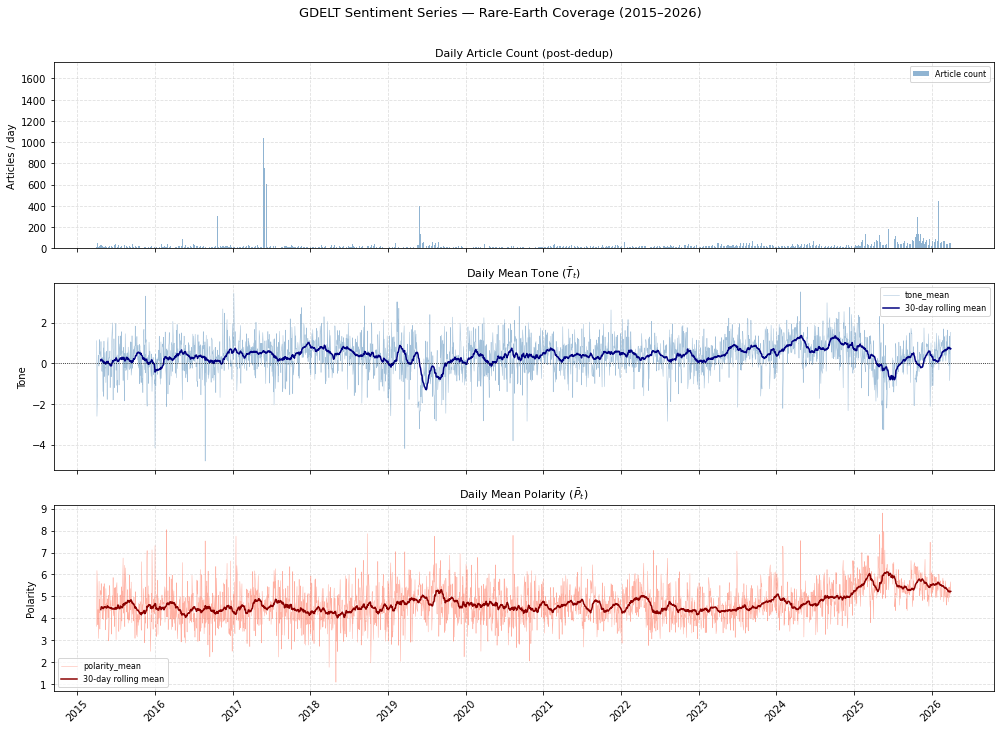

In [67]:
plot_data = merged.loc[sent_start:sent_end].copy()
roll = plot_data[['tone_mean', 'polarity_mean']].rolling(30, min_periods=15).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 — article count
axes[0].bar(plot_data.index, plot_data['article_count'],
            width=1, color='steelblue', alpha=0.6, label='Article count')
axes[0].set_ylabel('Articles / day')
axes[0].set_title('Daily Article Count (post-dedup)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend(fontsize=8)

# Panel 2 — tone_mean
axes[1].plot(plot_data.index, plot_data['tone_mean'],
             linewidth=0.5, color='steelblue', alpha=0.5, label='tone_mean')
axes[1].plot(roll.index, roll['tone_mean'],
             linewidth=1.5, color='navy', label='30-day rolling mean')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_ylabel('Tone')
axes[1].set_title('Daily Mean Tone ($\\bar{T}_t$)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend(fontsize=8)

# Panel 3 — polarity_mean
axes[2].plot(plot_data.index, plot_data['polarity_mean'],
             linewidth=0.5, color='tomato', alpha=0.5, label='polarity_mean')
axes[2].plot(roll.index, roll['polarity_mean'],
             linewidth=1.5, color='darkred', label='30-day rolling mean')
axes[2].set_ylabel('Polarity')
axes[2].set_title('Daily Mean Polarity ($\\bar{P}_t$)', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.4)
axes[2].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('GDELT Sentiment Series — Rare-Earth Coverage (2015–2026)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 18 — Export Combined Panel and Final Summary

The fully merged panel — containing price, log return, fill-flag, and sentiment columns aligned on a common business-day index — is saved to `CLEANED DATA/RRE_prices_sentiment_combined.xlsx`. This is the primary input file for all downstream volatility models (EGARCH-X, GJR-GARCH-X, DCC).

Columns are ordered thematically: prices → log returns → fill flags → sentiment aggregates → per-metal article counts.

In [68]:
FINAL_COLS = [
    'Nd_price',    'Pr_price',    'Dy_price',    'Tb_price',
    'Nd_logret',   'Pr_logret',   'Dy_logret',   'Tb_logret',
    'Nd_is_filled','Pr_is_filled','Dy_is_filled','Tb_is_filled',
    'tone_mean',   'polarity_mean','neg_tone_mean',
    'article_count','log_volume',
    'n_nd','n_pr','n_tb','n_dy','n_ndpr','n_ndfeb','n_rare_earth',
]

combined = merged.reindex(columns=FINAL_COLS)

out_combined = 'CLEANED DATA/RRE_prices_sentiment_combined.xlsx'
combined.reset_index().rename(columns={'index': 'Date'}).to_excel(out_combined, index=False)
print(f'Saved : {out_combined}')
print(f'Shape : {combined.shape}  ({combined.shape[0]:,} rows \u00d7 {combined.shape[1]} columns)')
print()

# ── Final summary table ───────────────────────────────────────────────────────
in_cov   = (merged.index >= sent_start) & (merged.index <= sent_end)
tot_bdays = len(merged)
cov_bdays = int(in_cov.sum())
non_zero  = int((in_cov & (merged['article_count'] > 0)).sum())

n_raw_articles  = int(n_raw)           # captured in Step 12 code
n_dedup_articles = len(sent_dedup)

summary_data = {
    'Metric': [
        'Sentiment coverage start',
        'Sentiment coverage end',
        'Total articles (raw)',
        'Total articles (after dedup)',
        'Trading days in panel (total)',
        'Trading days within coverage',
        'Trading days with \u22651 article',
        'n_nd  (Neodymium articles)',
        'n_pr  (Praseodymium articles)',
        'n_dy  (Dysprosium articles)',
        'n_tb  (Terbium articles)',
        'n_ndpr (NdPr articles)',
        'n_ndfeb (NdFeB articles)',
        'n_rare_earth (generic REE)',
    ],
    'Value': [
        str(sent_start.date()),
        str(sent_end.date()),
        f'{n_raw_articles:,}',
        f'{n_dedup_articles:,}',
        f'{tot_bdays:,}',
        f'{cov_bdays:,}',
        f'{non_zero:,}',
        f'{int(merged["n_nd"].sum()):,}',
        f'{int(merged["n_pr"].sum()):,}',
        f'{int(merged["n_dy"].sum()):,}',
        f'{int(merged["n_tb"].sum()):,}',
        f'{int(merged["n_ndpr"].sum()):,}',
        f'{int(merged["n_ndfeb"].sum()):,}',
        f'{int(merged["n_rare_earth"].sum()):,}',
    ]
}

summary_final = pd.DataFrame(summary_data).set_index('Metric')
print('Final Summary Table')
print('=' * 55)
print(summary_final.to_string())

Saved : CLEANED DATA/RRE_prices_sentiment_combined.xlsx
Shape : (2871, 24)  (2,871 rows × 24 columns)

Final Summary Table
                                    Value
Metric                                   
Sentiment coverage start       2015-04-01
Sentiment coverage end         2026-04-01
Total articles (raw)               98,253
Total articles (after dedup)       80,077
Trading days in panel (total)       2,871
Trading days within coverage        2,871
Trading days with ≥1 article        2,858
n_nd  (Neodymium articles)          2,442
n_pr  (Praseodymium articles)       1,810
n_dy  (Dysprosium articles)           509
n_tb  (Terbium articles)              907
n_ndpr (NdPr articles)                436
n_ndfeb (NdFeB articles)              453
n_rare_earth (generic REE)         75,180
